##  Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline

## 1. Utility Functions

Reusable helpers for data loading, preprocessing, and model evaluation.

In [2]:
def load_data(filepath="diabetes.csv"):
    """Load the Pima Indians Diabetes dataset."""
    return pd.read_csv(filepath)


def replace_zeros_with_nan(df, columns):
    """Replace 0 values with NaN for columns where 0 is biologically impossible."""
    df_clean = df.copy()
    for col in columns:
        df_clean[col] = df_clean[col].replace(0, np.nan)
    return df_clean


def impute_missing(df, strategy="median"):
    """Impute NaN values using median (default) or mean."""
    df_imputed = df.copy()
    for col in df_imputed.columns:
        if df_imputed[col].isnull().sum() > 0:
            fill_val = df_imputed[col].median() if strategy == "median" else df_imputed[col].mean()
            df_imputed[col] = df_imputed[col].fillna(fill_val)
    return df_imputed


def create_features(df):
    """Engineer new categorical features from existing numeric columns."""
    df_feat = df.copy()
    df_feat["BMI_Category"] = pd.cut(
        df_feat["BMI"], bins=[0, 18.5, 25, 30, 100],
        labels=["Underweight", "Normal", "Overweight", "Obese"],
    )
    df_feat["AgeGroup"] = pd.cut(
        df_feat["Age"], bins=[20, 30, 40, 50, 60, 90],
        labels=["20s", "30s", "40s", "50s", "60+"],
    )
    df_feat["Glucose_Category"] = pd.cut(
        df_feat["Glucose"], bins=[0, 99, 126, 300],
        labels=["Normal", "Prediabetes", "Diabetes"],
    )
    df_feat["Insulin_Category"] = pd.cut(
        df_feat["Insulin"], bins=[0, 16, 166, 900],
        labels=["Low", "Normal", "High"],
    )
    df_feat["BP_Category"] = pd.cut(
        df_feat["BloodPressure"], bins=[0, 80, 89, 200],
        labels=["Normal", "High_Stage1", "High_Stage2"],
    )
    return df_feat


def evaluate_model(model_name, y_true, y_pred):
    """Print and return a dict of classification metrics."""
    metrics = {
        "Model":     model_name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1 Score":  f1_score(y_true, y_pred),
    }
    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"  {k:12s}: {v:.4f}")
    return metrics


def plot_confusion_matrix(y_true, y_pred, model_name, ax=None):
    """Plot a labelled confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Diabetes", "Diabetes"],
        yticklabels=["No Diabetes", "Diabetes"], ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {model_name}")
    return ax


def plot_roc_curves(models_dict, X_test, y_test):
    """Plot ROC curves for multiple models on the same axes."""
    plt.figure(figsize=(10, 7))
    for name, model in models_dict.items():
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_prob = model.decision_function(X_test)
        else:
            continue
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves — Model Comparison")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def cross_validate_model(model, X, y, cv=5):
    """Run k-fold cross-validation and print F1 summary."""
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1")
    print(f"  CV F1 Scores : {scores.round(4)}")
    print(f"  Mean F1      : {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores


def compare_models(results_list):
    """Create a comparison DataFrame sorted by F1 Score."""
    df_r = pd.DataFrame(results_list)
    return df_r.sort_values("F1 Score", ascending=False).reset_index(drop=True)

## 2. Load Data

In [3]:
df = load_data("diabetes.csv")
print(f"Dataset shape : {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
df.head(10)

Dataset shape : (768, 9)
Duplicate rows: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## 3. Exploratory Data Analysis

### 3.1 Invalid Zero Values

Several columns use **0** as a placeholder for missing values (e.g. 0 Glucose or 0 Blood Pressure is biologically impossible).

In [6]:
FEATURES     = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
ZERO_INVALID = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Count of 0 values (likely missing):")
print("-" * 35)
for col in ZERO_INVALID:
    count = (df[col] == 0).sum()
    pct   = count / len(df) * 100
    print(f"  {col:25s}: {count:3d} ({pct:.1f}%)")

Count of 0 values (likely missing):
-----------------------------------
  Glucose                  :   5 (0.7%)
  BloodPressure            :  35 (4.6%)
  SkinThickness            : 227 (29.6%)
  Insulin                  : 374 (48.7%)
  BMI                      :  11 (1.4%)


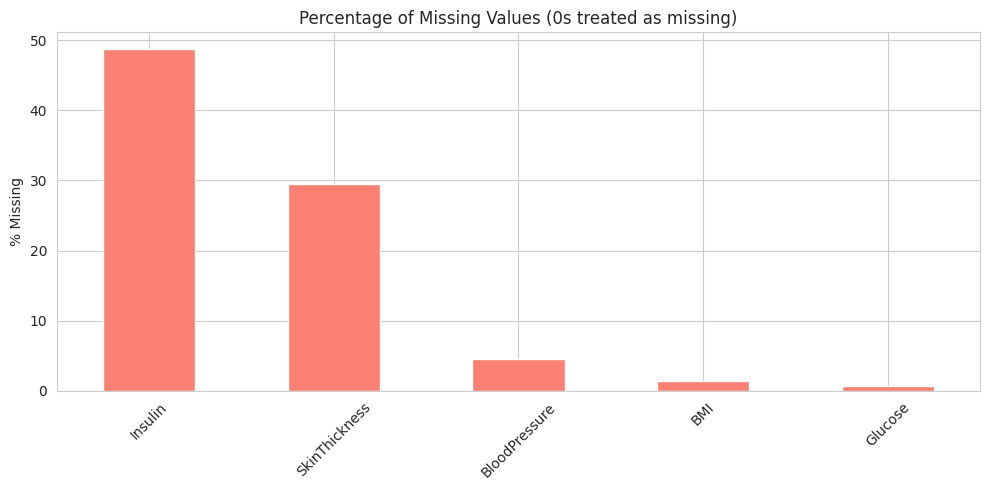

In [7]:
df_missing  = replace_zeros_with_nan(df, ZERO_INVALID)
missing_pct = (df_missing.isnull().sum() / len(df_missing) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 5))
missing_pct.plot(kind="bar", color="salmon", ax=ax)
ax.set_title("Percentage of Missing Values (0s treated as missing)")
ax.set_ylabel("% Missing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Target Variable Distribution

/tmp/ipykernel_782/3197597209.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, palette="Set2", ax=axes[0])
/tmp/ipykernel_782/3197597209.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])


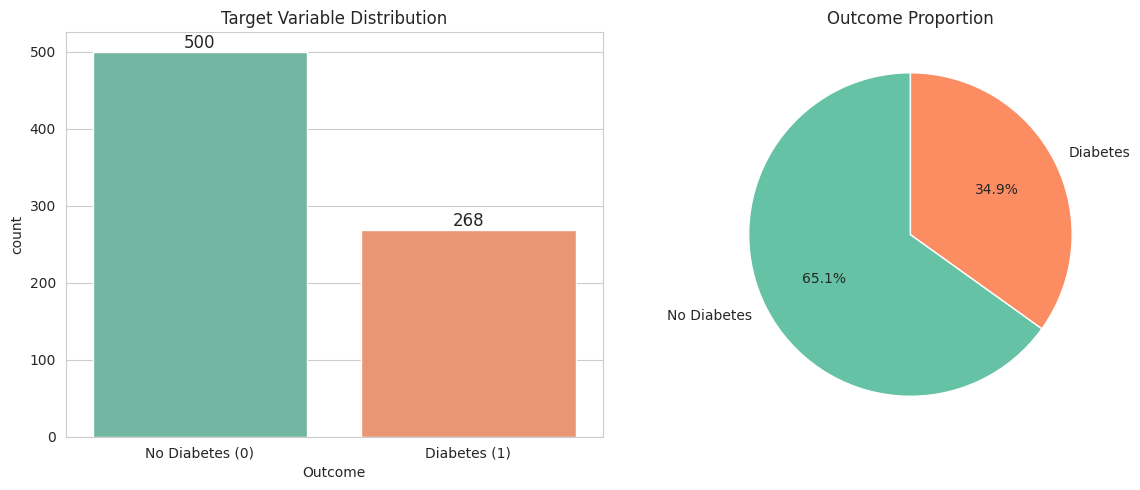

Diabetes rate: 34.9%
Outcome
0    500
1    268
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="Outcome", data=df, palette="Set2", ax=axes[0])
axes[0].set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])
axes[0].set_title("Target Variable Distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=12)

df["Outcome"].value_counts().plot.pie(
    labels=["No Diabetes", "Diabetes"], autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"], startangle=90, ax=axes[1],
)
axes[1].set_ylabel("")
axes[1].set_title("Outcome Proportion")
plt.tight_layout()
plt.show()
print(f"Diabetes rate: {df['Outcome'].mean():.1%}")
print(df["Outcome"].value_counts())

### 3.3 Feature Distributions

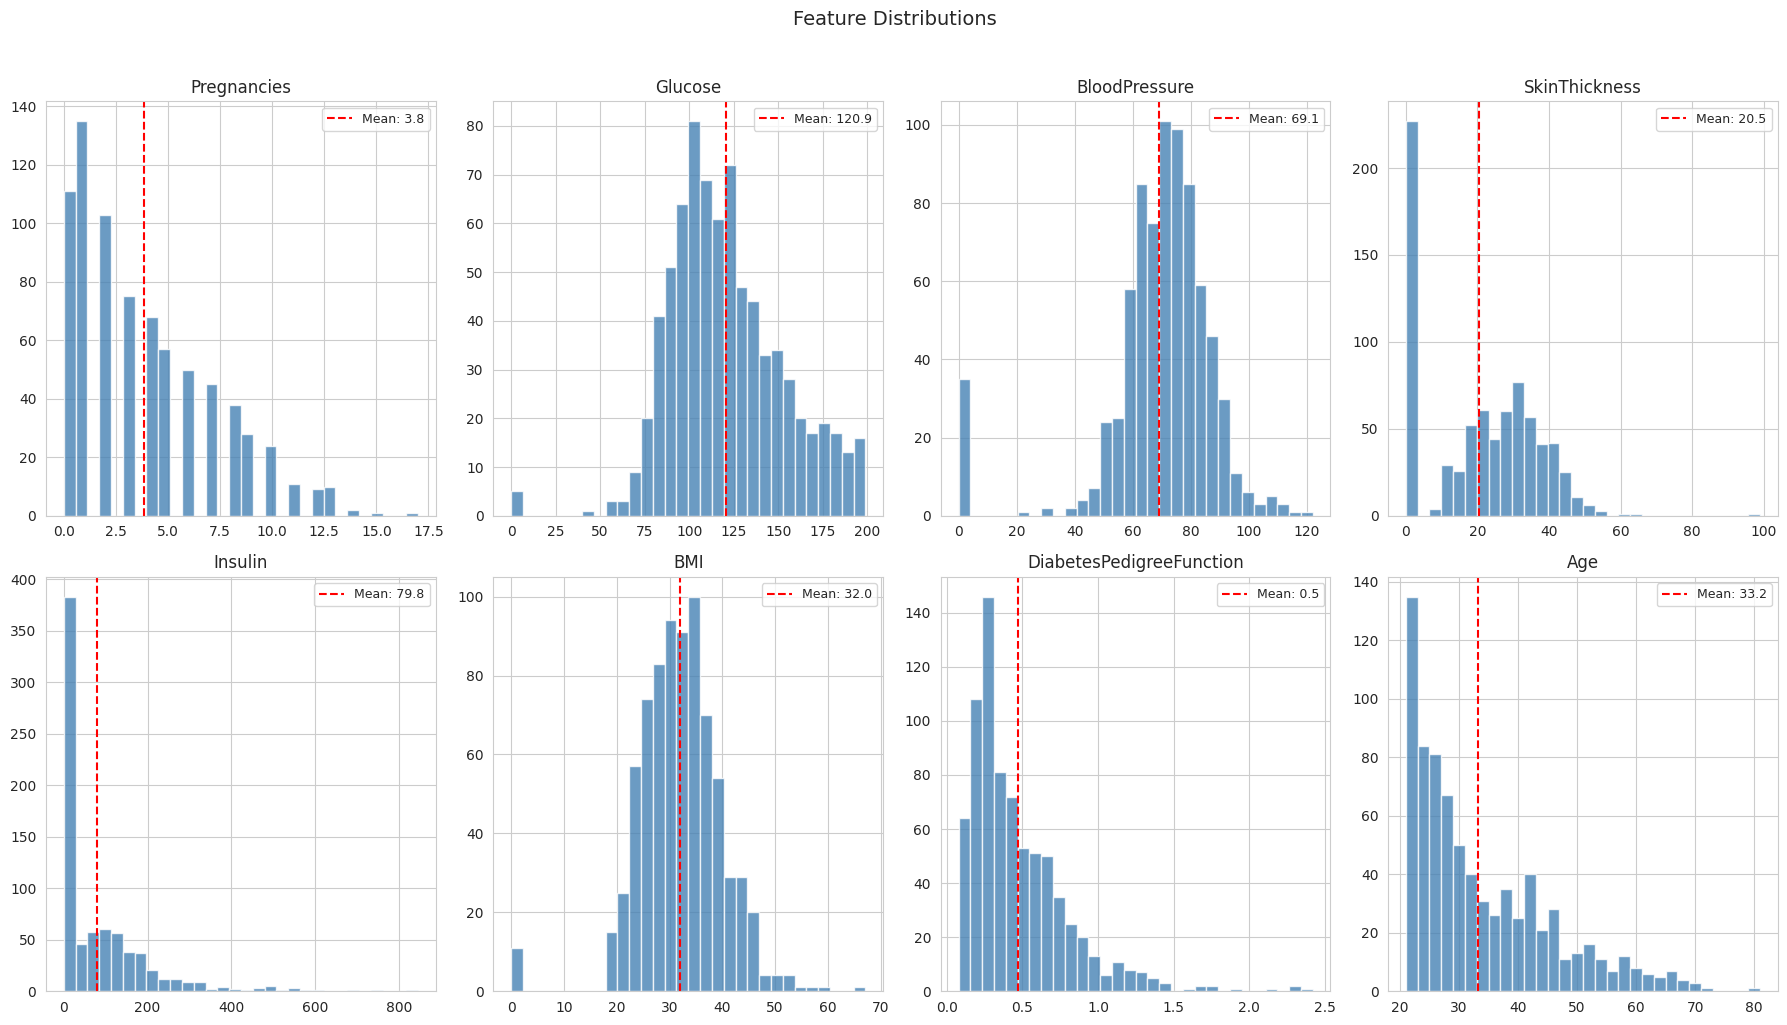

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--",
                    label=f"Mean: {df[col].mean():.1f}")
    axes[i].legend(fontsize=9)
plt.suptitle("Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

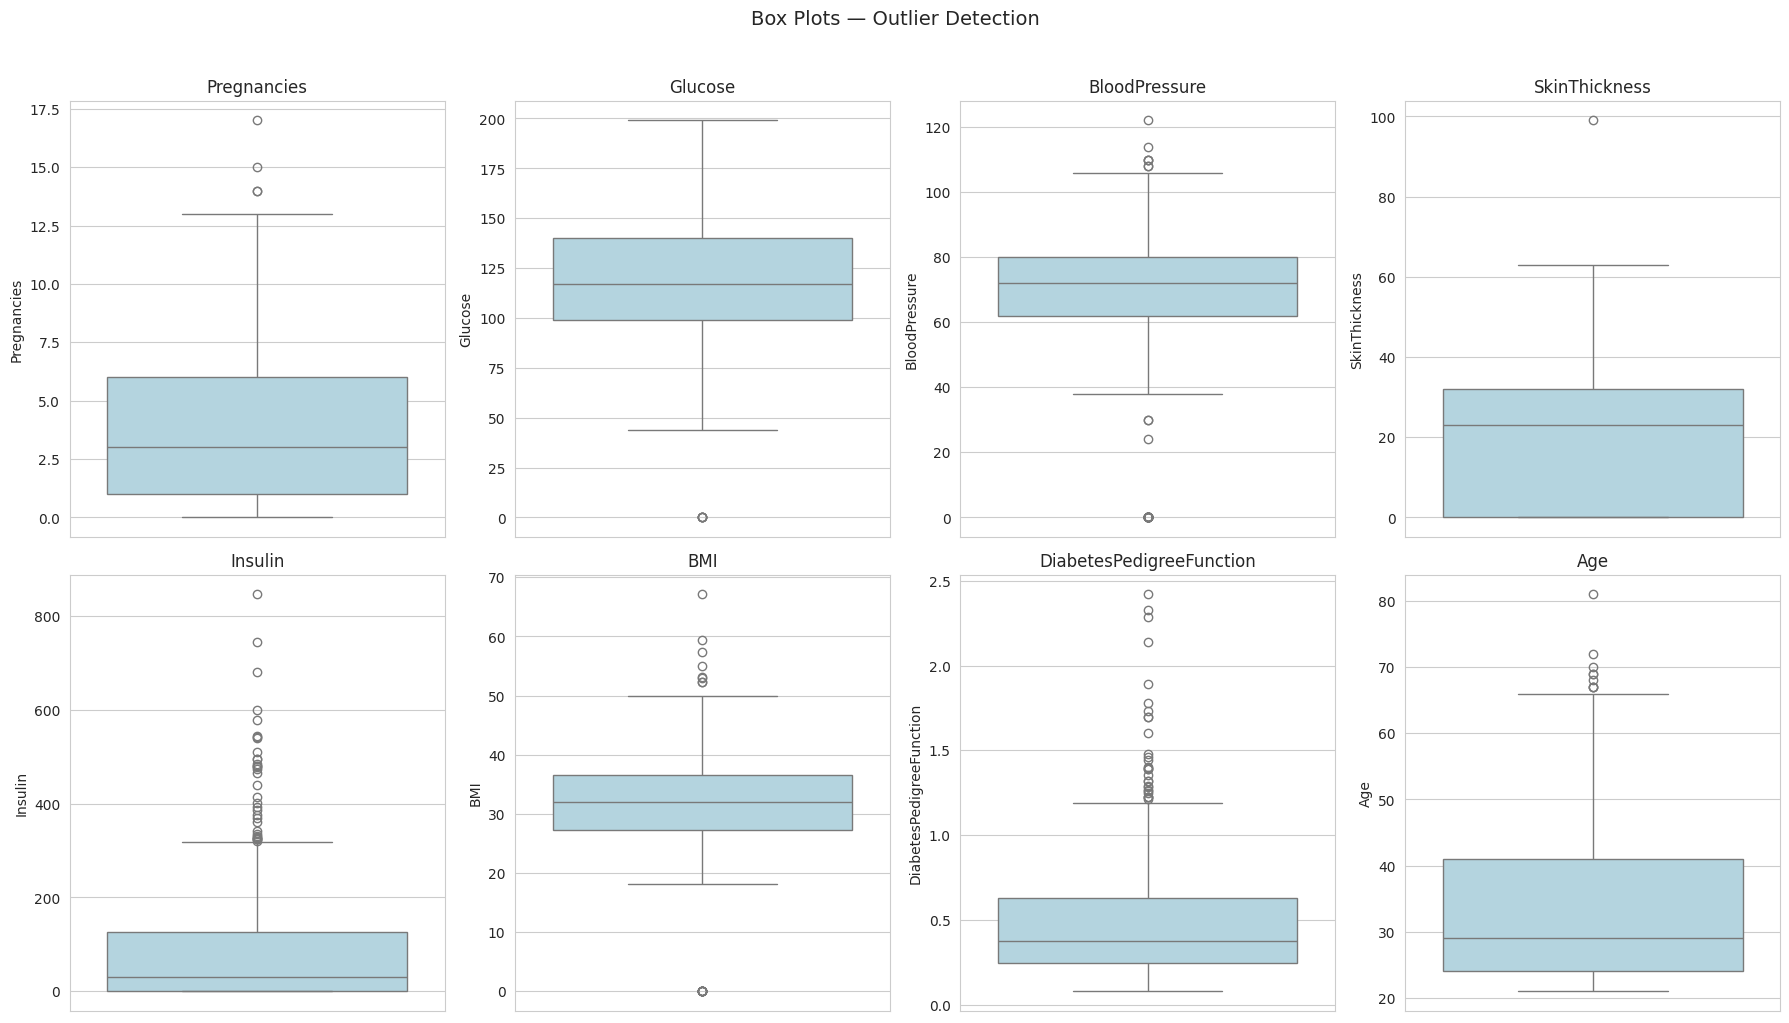

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col)
plt.suptitle("Box Plots — Outlier Detection", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Feature Distributions by Outcome

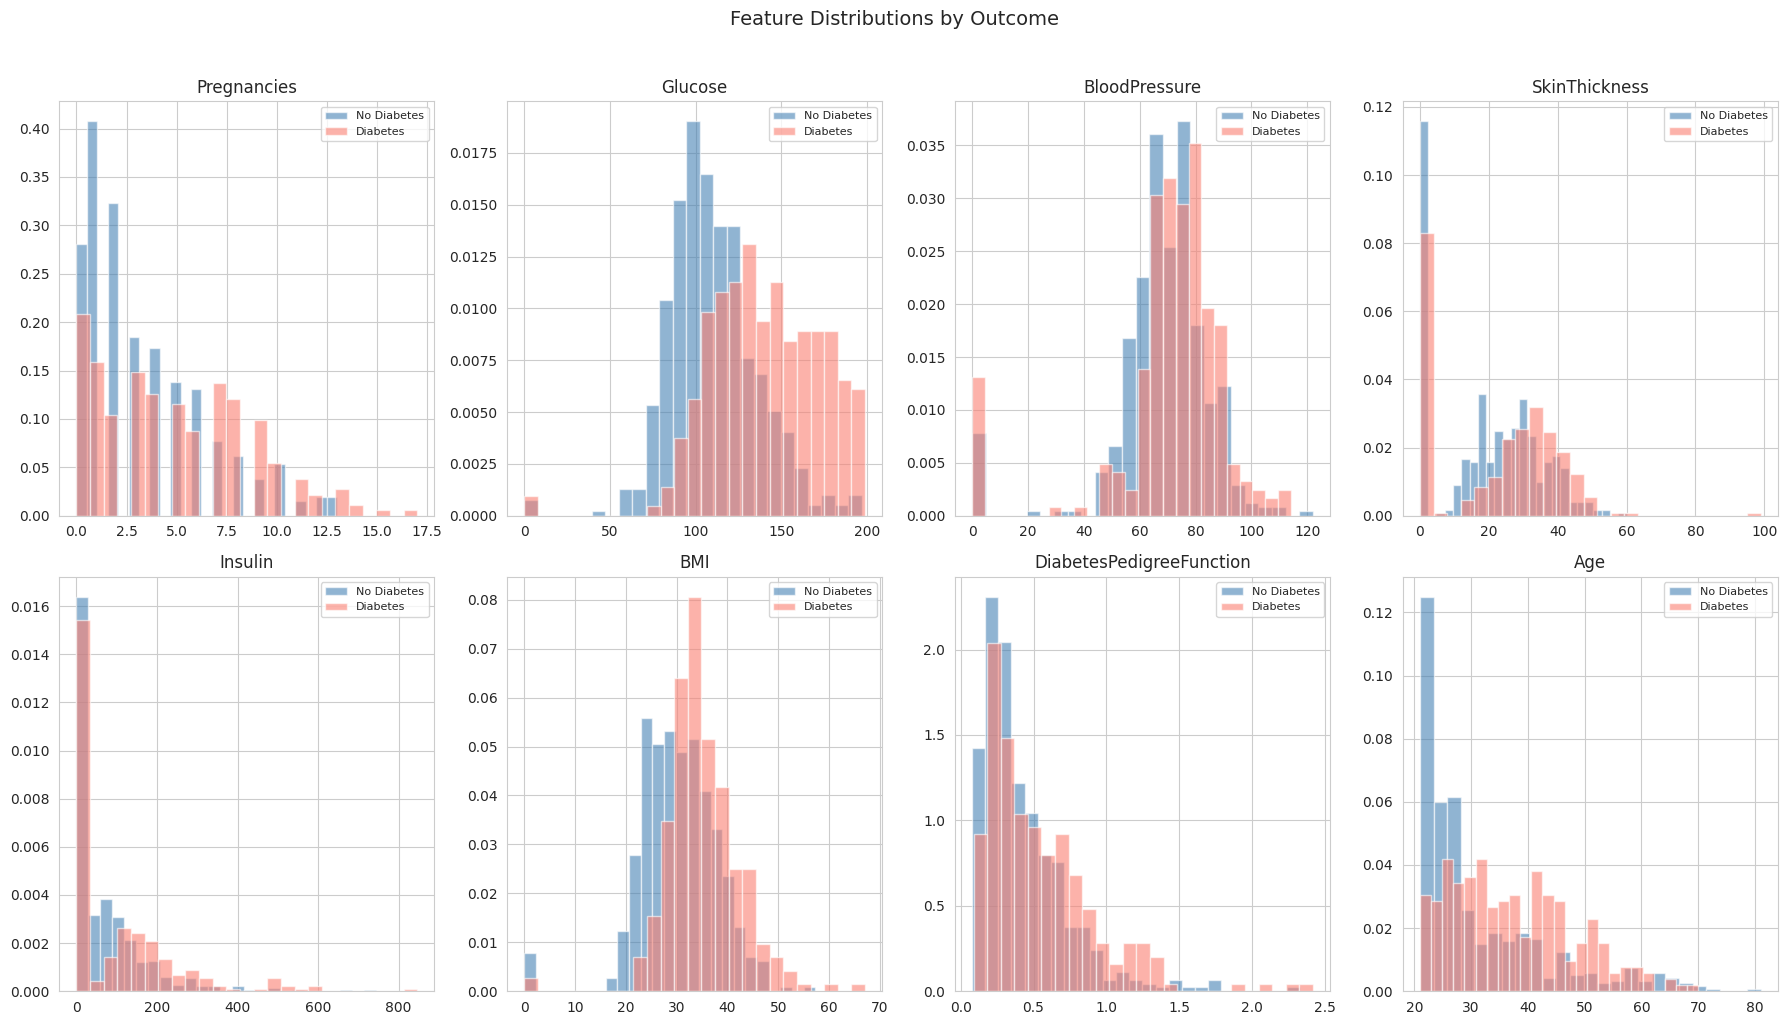

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    for outcome, color, label in [(0, "steelblue", "No Diabetes"), (1, "salmon", "Diabetes")]:
        subset = df[df["Outcome"] == outcome][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
plt.suptitle("Feature Distributions by Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
comparison = df.groupby("Outcome")[FEATURES].mean().T
comparison.columns = ["No Diabetes", "Diabetes"]
comparison["Difference"] = comparison["Diabetes"] - comparison["No Diabetes"]
comparison["% Higher"]   = (comparison["Difference"] / comparison["No Diabetes"] * 100).round(1)
comparison.round(2)

,No Diabetes,Diabetes,Difference,% Higher
Pregnancies,3.30,4.87,1.57,47.5
Glucose,109.98,141.26,31.28,28.4
BloodPressure,68.18,70.82,2.64,3.9
SkinThickness,19.66,22.16,2.50,12.7
Insulin,68.79,100.34,31.54,45.9
BMI,30.30,35.14,4.84,16.0
DiabetesPedigreeFunction,0.43,0.55,0.12,28.1
Age,31.19,37.07,5.88,18.8


/tmp/ipykernel_782/879455845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Outcome", y=col, data=df, palette="Set2", ax=axes[i])
/tmp/ipykernel_782/879455845.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Diabetes", "Diabetes"])
/tmp/ipykernel_782/879455845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Outcome", y=col, data=df, palette="Set2", ax=axes[i])
/tmp/ipykernel_782/879455845.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Diab

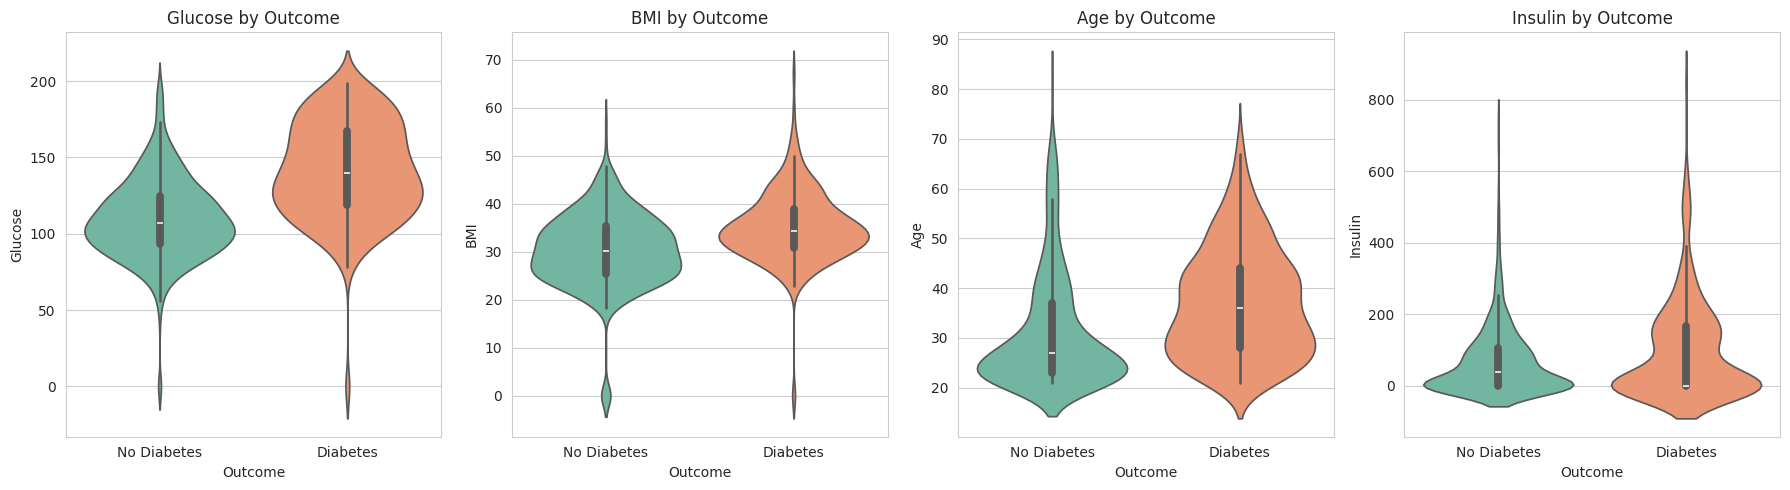

In [13]:
key_features = ["Glucose", "BMI", "Age", "Insulin"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(key_features):
    sns.violinplot(x="Outcome", y=col, data=df, palette="Set2", ax=axes[i])
    axes[i].set_xticklabels(["No Diabetes", "Diabetes"])
    axes[i].set_title(f"{col} by Outcome")
plt.tight_layout()
plt.show()

### 3.5 Correlation Analysis

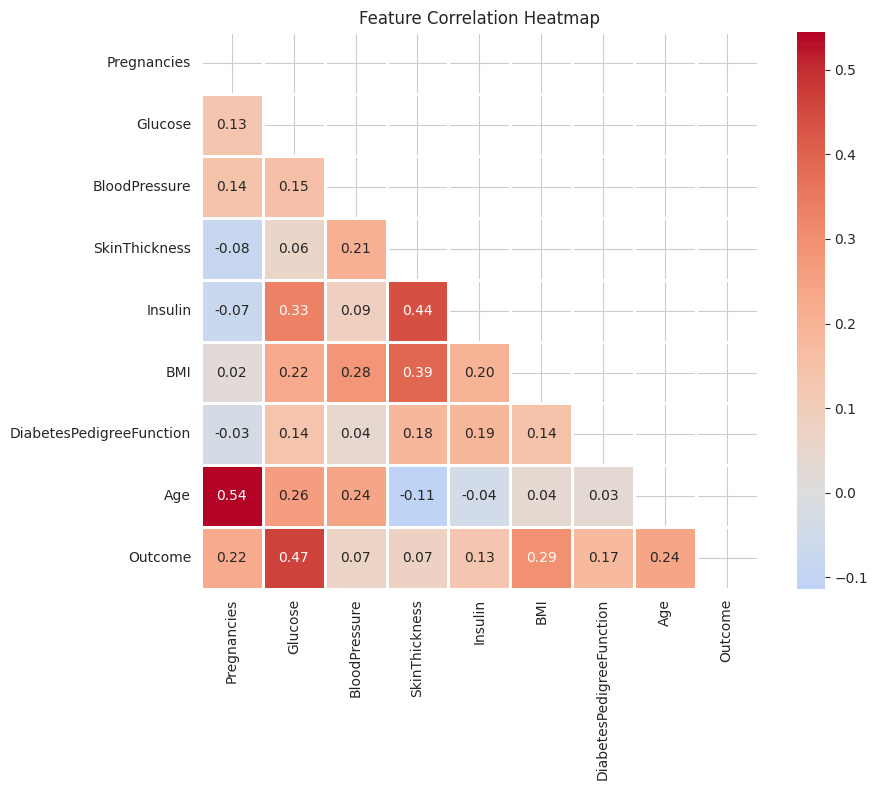

In [14]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

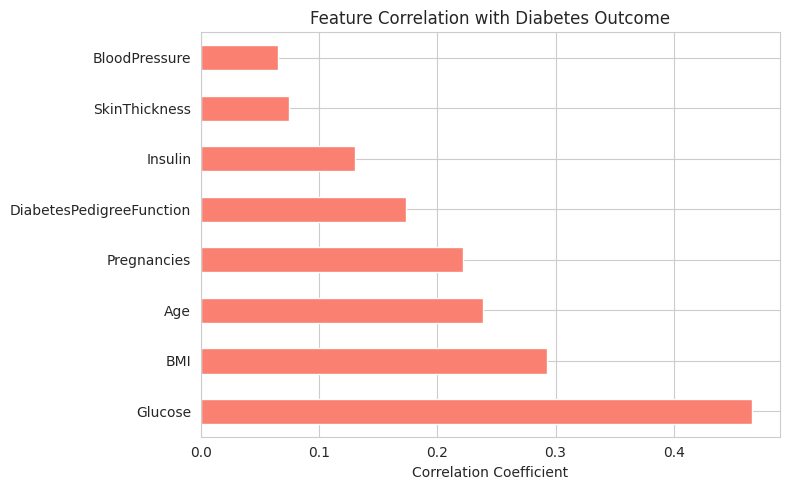

Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065
Name: Outcome, dtype: float64


In [15]:
target_corr = df.corr()["Outcome"].drop("Outcome").sort_values(ascending=False)
plt.figure(figsize=(8, 5))
target_corr.plot(kind="barh",
                 color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature Correlation with Diabetes Outcome")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()
print(target_corr.round(3))

### 3.6 Age, Pregnancy & Glucose Analysis

/tmp/ipykernel_782/2501970182.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df_tmp.groupby("AgeGroup")["Outcome"].mean() * 100).plot(
/tmp/ipykernel_782/2501970182.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df_tmp.groupby("Preg_Group")["Outcome"].mean() * 100).plot(


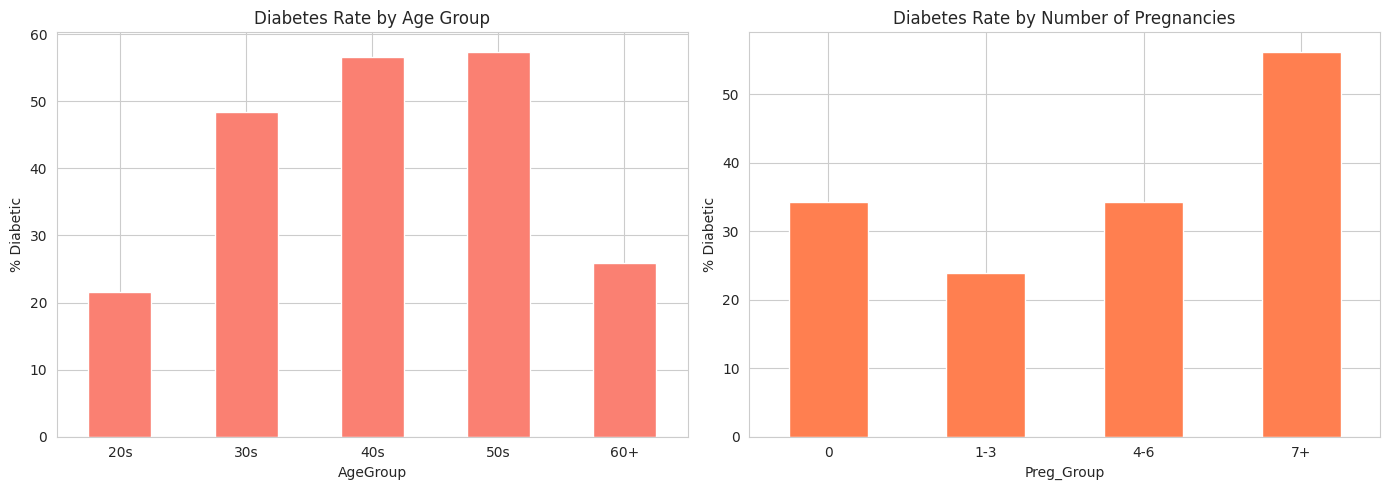

In [16]:
df_tmp = df.copy()
df_tmp["AgeGroup"]   = pd.cut(df_tmp["Age"], bins=[20, 30, 40, 50, 60, 90],
                               labels=["20s", "30s", "40s", "50s", "60+"])
df_tmp["Preg_Group"] = pd.cut(df_tmp["Pregnancies"], bins=[-1, 0, 3, 6, 20],
                               labels=["0", "1-3", "4-6", "7+"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(df_tmp.groupby("AgeGroup")["Outcome"].mean() * 100).plot(
    kind="bar", color="salmon", ax=axes[0])
axes[0].set_title("Diabetes Rate by Age Group")
axes[0].set_ylabel("% Diabetic")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

(df_tmp.groupby("Preg_Group")["Outcome"].mean() * 100).plot(
    kind="bar", color="coral", ax=axes[1])
axes[1].set_title("Diabetes Rate by Number of Pregnancies")
axes[1].set_ylabel("% Diabetic")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

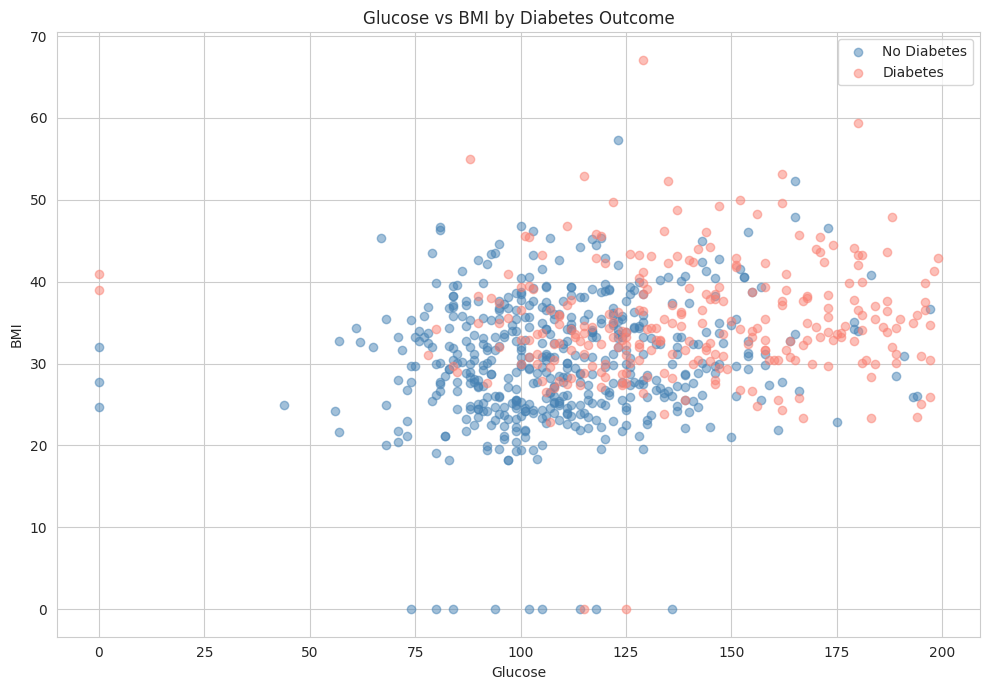

Diabetes rate by glucose level:
----------------------------------------
  Normal (<100)            : 8.1% (n=197)
  Prediabetes (100-126)    : 27.7% (n=274)
  Diabetes (>126)          : 59.3% (n=297)


In [17]:
plt.figure(figsize=(10, 7))
for outcome, color, label in [(0, "steelblue", "No Diabetes"), (1, "salmon", "Diabetes")]:
    subset = df[df["Outcome"] == outcome]
    plt.scatter(subset["Glucose"], subset["BMI"], c=color, alpha=0.5, label=label)
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI by Diabetes Outcome")
plt.legend()
plt.tight_layout()
plt.show()

print("Diabetes rate by glucose level:")
print("-" * 40)
for lbl, low, high in [("Normal (<100)", 0, 100),
                        ("Prediabetes (100-126)", 100, 126),
                        ("Diabetes (>126)", 126, 300)]:
    subset = df[(df["Glucose"] >= low) & (df["Glucose"] < high)]
    rate   = subset["Outcome"].mean() * 100
    print(f"  {lbl:25s}: {rate:.1f}% (n={len(subset)})")

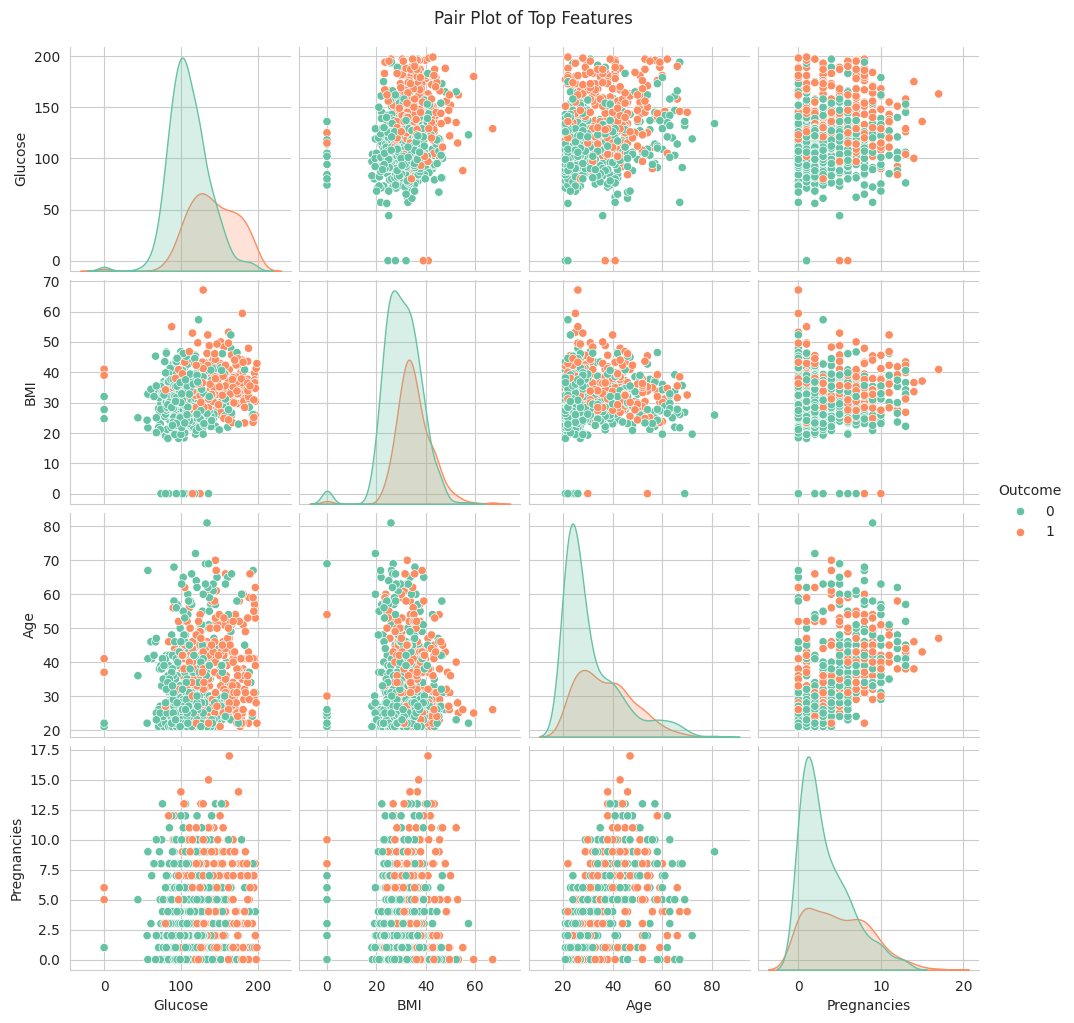

In [18]:
top_features = ["Glucose", "BMI", "Age", "Pregnancies", "Outcome"]
sns.pairplot(df[top_features], hue="Outcome", palette="Set2", diag_kind="kde")
plt.suptitle("Pair Plot of Top Features", y=1.02)
plt.show()

## 4. Data Cleaning & Feature Engineering

### 4.1 Replace Invalid Zeros → NaN

In [19]:
print("Zero counts BEFORE replacement:")
for col in ZERO_INVALID:
    print(f"  {col:25s}: {(df[col] == 0).sum()}")

df_clean = replace_zeros_with_nan(df, ZERO_INVALID)
print("\nMissing values AFTER replacement:")
print(df_clean.isnull().sum())
print(f"Total missing: {df_clean.isnull().sum().sum()}")

Zero counts BEFORE replacement:
  Glucose                  : 5
  BloodPressure            : 35
  SkinThickness            : 227
  Insulin                  : 374
  BMI                      : 11

Missing values AFTER replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Total missing: 652


### 4.2 Median Imputation

In [20]:
print("Median values used for imputation:")
for col in ZERO_INVALID:
    print(f"  {col:25s}: {df_clean[col].median():.1f}")

df_clean = impute_missing(df_clean, strategy="median")
print(f"\nMissing values after imputation: {df_clean.isnull().sum().sum()}")

Median values used for imputation:
  Glucose                  : 117.0
  BloodPressure            : 72.0
  SkinThickness            : 29.0
  Insulin                  : 125.0
  BMI                      : 32.3

Missing values after imputation: 0


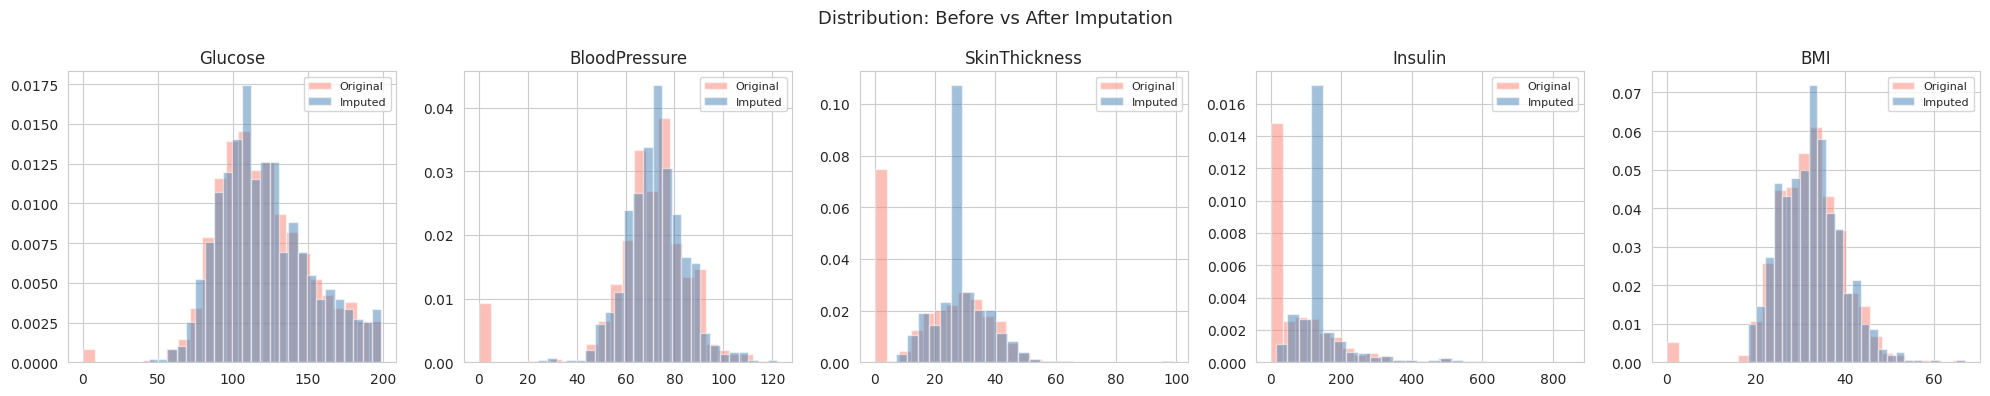

In [21]:
fig, axes = plt.subplots(1, len(ZERO_INVALID), figsize=(20, 4))
for i, col in enumerate(ZERO_INVALID):
    axes[i].hist(df[col],       bins=25, alpha=0.5, color="salmon",    label="Original", density=True)
    axes[i].hist(df_clean[col], bins=25, alpha=0.5, color="steelblue", label="Imputed",  density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
plt.suptitle("Distribution: Before vs After Imputation", fontsize=13)
plt.tight_layout()
plt.show()

### 4.3 Feature Engineering

In [22]:
df_feat = create_features(df_clean)
print(f"Shape after feature engineering: {df_feat.shape}")
print(f"New columns: {set(df_feat.columns) - set(df_clean.columns)}")
df_feat.head()

Shape after feature engineering: (768, 14)
New columns: {'AgeGroup', 'BP_Category', 'Insulin_Category', 'BMI_Category', 'Glucose_Category'}


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,AgeGroup,Glucose_Category,Insulin_Category,BP_Category
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Obese,40s,Diabetes,Normal,Normal
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Overweight,30s,Normal,Normal,Normal
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Normal,30s,Diabetes,Normal,Normal
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,20s,Normal,Normal,Normal
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,30s,Diabetes,High,Normal


/tmp/ipykernel_782/292335808.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_rate     = df_feat.groupby("BMI_Category")["Outcome"].mean() * 100
/tmp/ipykernel_782/292335808.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  glucose_rate = df_feat.groupby("Glucose_Category")["Outcome"].mean() * 100
/tmp/ipykernel_782/292335808.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate     = df_feat.groupby("Age

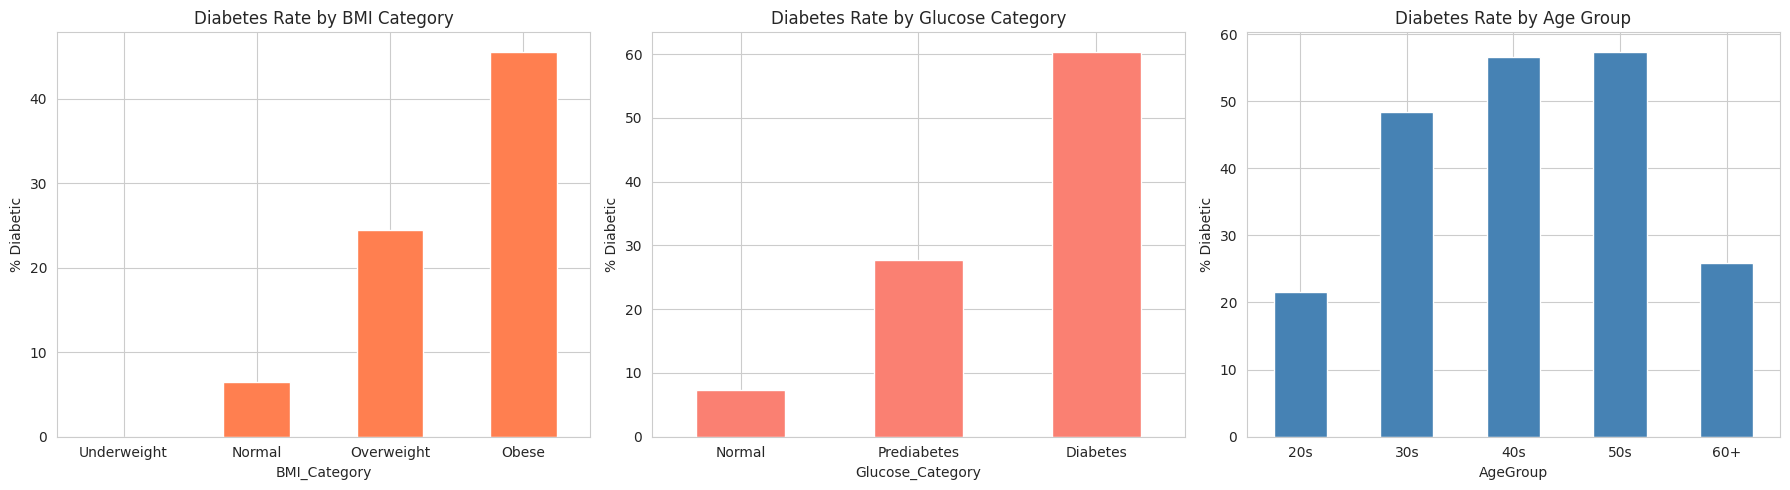

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bmi_rate     = df_feat.groupby("BMI_Category")["Outcome"].mean() * 100
glucose_rate = df_feat.groupby("Glucose_Category")["Outcome"].mean() * 100
age_rate     = df_feat.groupby("AgeGroup")["Outcome"].mean() * 100

bmi_rate.plot(kind="bar",     color="coral",     ax=axes[0])
glucose_rate.plot(kind="bar", color="salmon",    ax=axes[1])
age_rate.plot(kind="bar",     color="steelblue", ax=axes[2])

for ax, title in zip(axes, ["Diabetes Rate by BMI Category",
                              "Diabetes Rate by Glucose Category",
                              "Diabetes Rate by Age Group"]):
    ax.set_title(title)
    ax.set_ylabel("% Diabetic")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 4.4 One-Hot Encoding

In [24]:
CATEGORICAL_COLS = ["BMI_Category", "AgeGroup", "Glucose_Category",
                    "Insulin_Category", "BP_Category"]
df_encoded = pd.get_dummies(df_feat, columns=CATEGORICAL_COLS, drop_first=True)

print(f"Shape after encoding : {df_encoded.shape}")
print(f"Missing values       : {df_encoded.isnull().sum().sum()}")
df_encoded.head()

Shape after encoding : (768, 22)
Missing values       : 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category_Normal,...,AgeGroup_30s,AgeGroup_40s,AgeGroup_50s,AgeGroup_60+,Glucose_Category_Prediabetes,Glucose_Category_Diabetes,Insulin_Category_Normal,Insulin_Category_High,BP_Category_High_Stage1,BP_Category_High_Stage2
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,False,...,False,True,False,False,False,True,True,False,False,False
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,False,...,True,False,False,False,False,False,True,False,False,False
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,True,...,True,False,False,False,False,True,True,False,False,False
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,False,...,False,False,False,False,False,False,True,False,False,False
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,False,...,True,False,False,False,False,True,False,True,False,False


## 5. Model Building & Evaluation

### 5.1 Prepare Features & Train/Test Split

In [25]:
X = df_encoded.drop("Outcome", axis=1)
y = df_encoded["Outcome"]

print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features : 21
Samples  : 768

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]} samples  |  Test : {X_test.shape[0]} samples")
print(f"Train target dist : {dict(y_train.value_counts())}")
print(f"Test  target dist : {dict(y_test.value_counts())}")

# Feature scaling (needed for KNN, SVM, Logistic Regression)
SCALE_NEEDED    = {"Logistic Regression", "KNN", "SVM"}
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

Train : 614 samples  |  Test : 154 samples
Train target dist : {0: np.int64(400), 1: np.int64(214)}
Test  target dist : {0: np.int64(100), 1: np.int64(54)}


### 5.2 Logistic Regression


  Logistic Regression
  Accuracy    : 0.7468
  Precision   : 0.6596
  Recall      : 0.5741
  F1 Score    : 0.6139


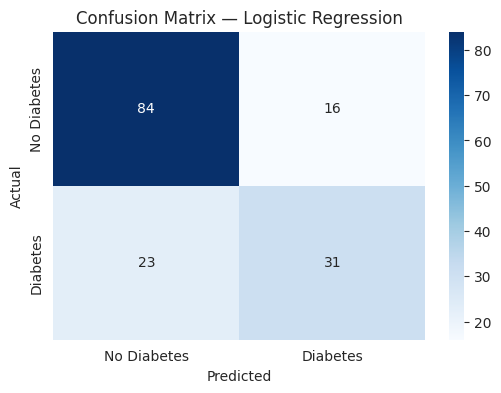

In [27]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

results        = []
trained_models = {}

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr))
trained_models["Logistic Regression"] = lr
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")
plt.show()

### 5.3 Decision Tree


  Decision Tree
  Accuracy    : 0.7403
  Precision   : 0.6061
  Recall      : 0.7407
  F1 Score    : 0.6667


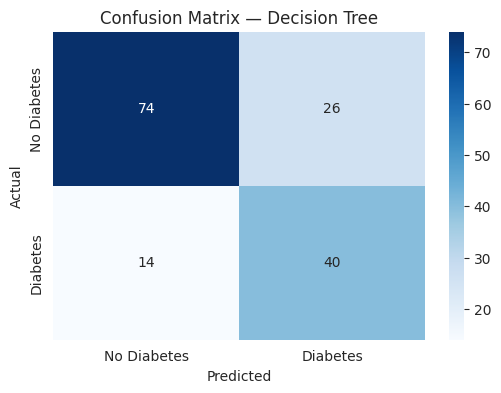

In [28]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

results.append(evaluate_model("Decision Tree", y_test, y_pred_dt))
trained_models["Decision Tree"] = dt
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")
plt.show()

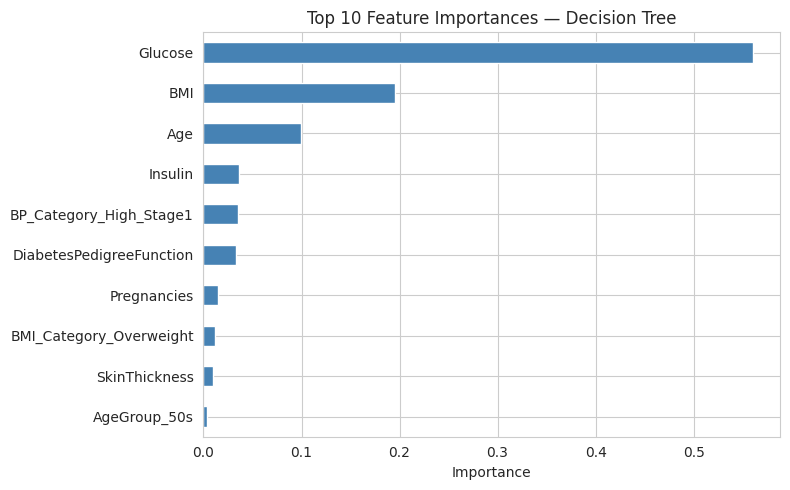

In [29]:
feat_imp_dt = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp_dt.tail(10).plot(kind="barh", color="steelblue", figsize=(8, 5))
plt.title("Top 10 Feature Importances — Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### 5.4 Random Forest


  Random Forest
  Accuracy    : 0.7727
  Precision   : 0.7021
  Recall      : 0.6111
  F1 Score    : 0.6535


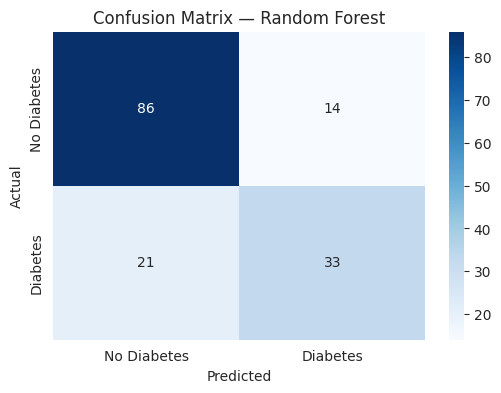

In [30]:
rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append(evaluate_model("Random Forest", y_test, y_pred_rf))
trained_models["Random Forest"] = rf
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
plt.show()

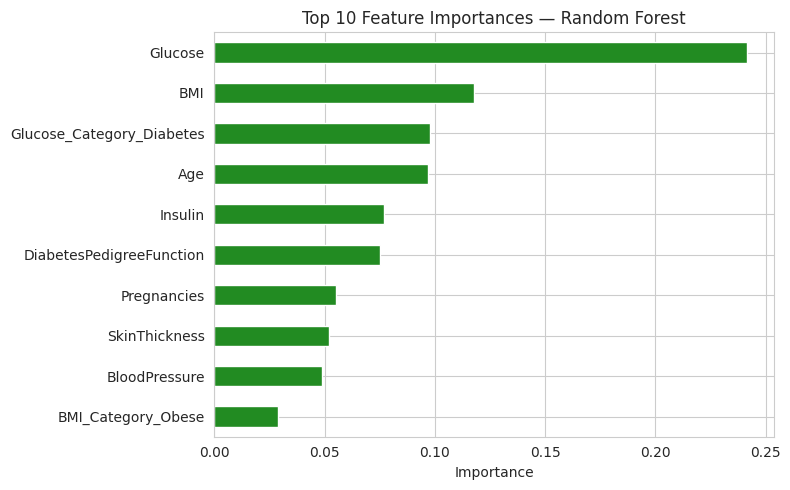

In [31]:
feat_imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp_rf.tail(10).plot(kind="barh", color="forestgreen", figsize=(8, 5))
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### 5.5 K-Nearest Neighbors

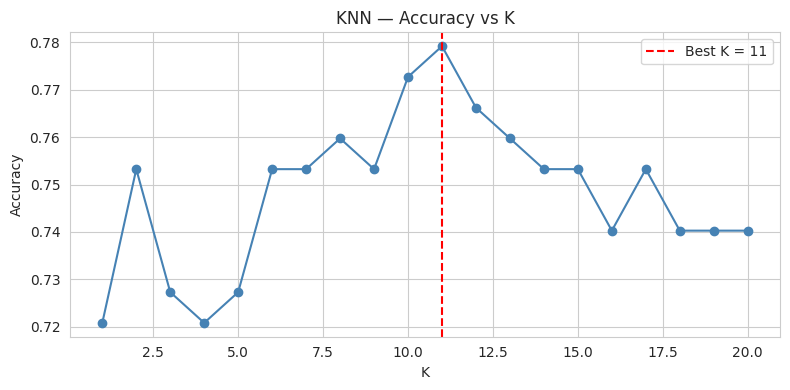

Best K = 11


In [32]:
k_range  = range(1, 21)
k_scores = []
for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    k_scores.append(knn_temp.score(X_test_scaled, y_test))

best_k = list(k_range)[np.argmax(k_scores)]
plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, marker="o", color="steelblue")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN — Accuracy vs K")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Best K = {best_k}")


  KNN
  Accuracy    : 0.7792
  Precision   : 0.6923
  Recall      : 0.6667
  F1 Score    : 0.6792


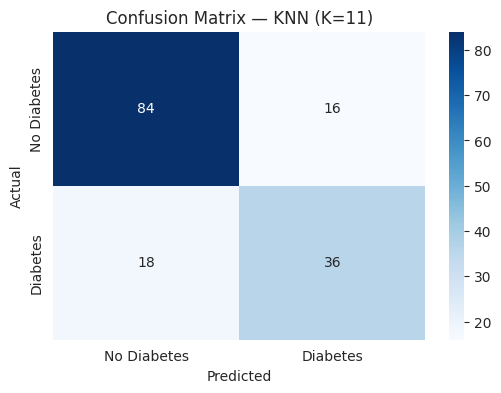

In [33]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

results.append(evaluate_model("KNN", y_test, y_pred_knn))
trained_models["KNN"] = knn
plot_confusion_matrix(y_test, y_pred_knn, f"KNN (K={best_k})")
plt.show()

### 5.6 Support Vector Machine


  SVM
  Accuracy    : 0.7532
  Precision   : 0.6481
  Recall      : 0.6481
  F1 Score    : 0.6481


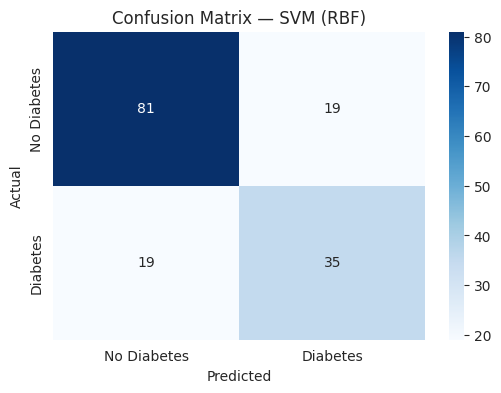

In [34]:
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

results.append(evaluate_model("SVM", y_test, y_pred_svm))
trained_models["SVM"] = svm
plot_confusion_matrix(y_test, y_pred_svm, "SVM (RBF)")
plt.show()

### 5.7 Gradient Boosting


  Gradient Boosting
  Accuracy    : 0.7532
  Precision   : 0.6667
  Recall      : 0.5926
  F1 Score    : 0.6275


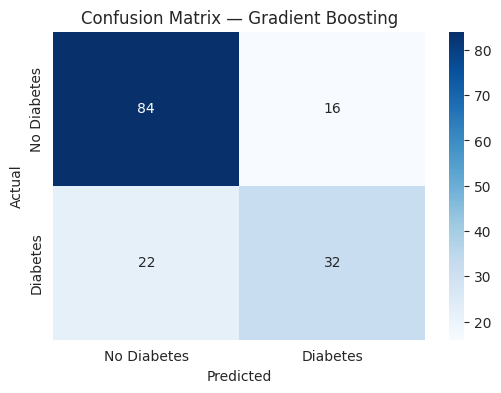

In [35]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))
trained_models["Gradient Boosting"] = gb
plot_confusion_matrix(y_test, y_pred_gb, "Gradient Boosting")
plt.show()

### 5.8 Naive Bayes


  Naive Bayes
  Accuracy    : 0.7013
  Precision   : 0.5606
  Recall      : 0.6852
  F1 Score    : 0.6167


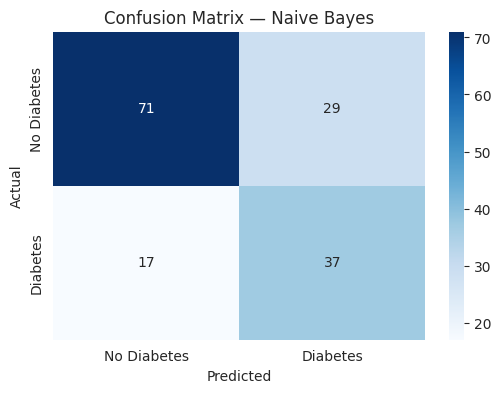

In [36]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

results.append(evaluate_model("Naive Bayes", y_test, y_pred_nb))
trained_models["Naive Bayes"] = nb
plot_confusion_matrix(y_test, y_pred_nb, "Naive Bayes")
plt.show()

## 6. Model Comparison

In [37]:
df_results = compare_models(results)
df_results

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.779221,0.692308,0.666667,0.679245
1,Decision Tree,0.740260,0.606061,0.740741,0.666667
2,Random Forest,0.772727,0.702128,0.611111,0.653465
3,SVM,0.753247,0.648148,0.648148,0.648148
4,Gradient Boosting,0.753247,0.666667,0.592593,0.627451
5,Naive Bayes,0.701299,0.560606,0.685185,0.616667
6,Logistic Regression,0.746753,0.659574,0.574074,0.613861


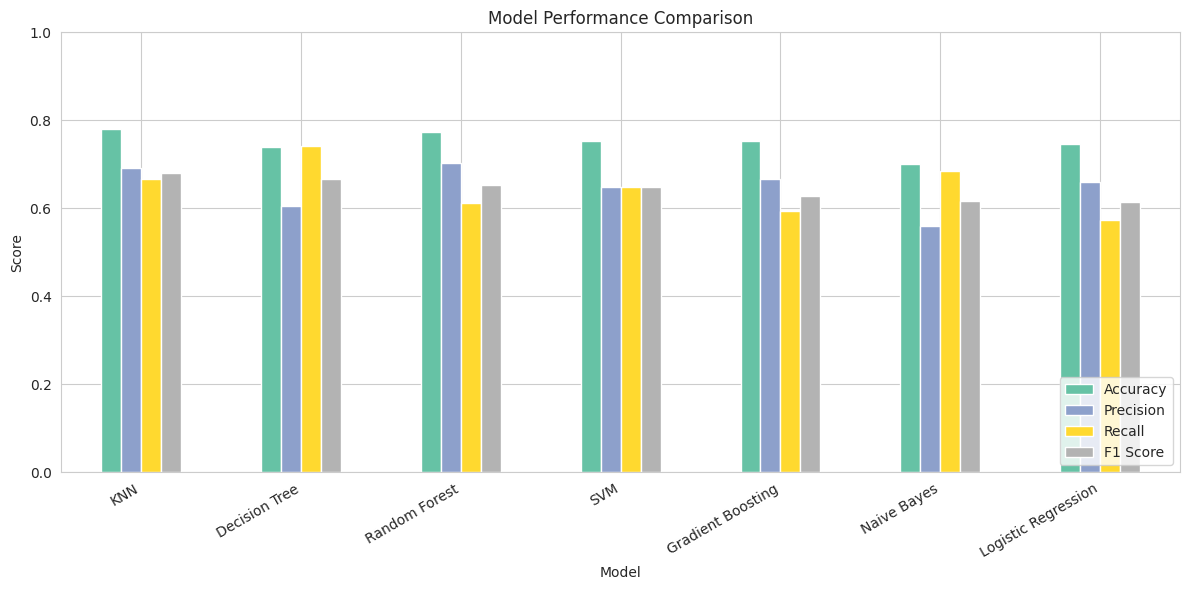

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
df_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", ax=ax, colormap="Set2"
)
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. 5-Fold Cross-Validation

In [39]:
models_for_cv = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=best_k),
    "SVM":                 SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                       max_depth=3, random_state=42),
    "Naive Bayes":         GaussianNB(),
}

cv_results = {}
for name, model in models_for_cv.items():
    print(f"\n{name}:")
    X_cv = X_train_scaled if name in SCALE_NEEDED else X_train
    cv_results[name] = cross_validate_model(model, X_cv, y_train, cv=5)


Logistic Regression:
  CV F1 Scores : [0.5823 0.6667 0.625  0.6667 0.7027]
  Mean F1      : 0.6487 (+/- 0.0413)

Decision Tree:
  CV F1 Scores : [0.6118 0.507  0.5205 0.6053 0.6222]
  Mean F1      : 0.5734 (+/- 0.0491)

Random Forest:
  CV F1 Scores : [0.6098 0.6914 0.5897 0.6027 0.6582]
  Mean F1      : 0.6304 (+/- 0.0383)

KNN:
  CV F1 Scores : [0.5789 0.6444 0.642  0.56   0.6914]
  Mean F1      : 0.6233 (+/- 0.0478)

SVM:
  CV F1 Scores : [0.5263 0.6824 0.6173 0.5634 0.641 ]
  Mean F1      : 0.6061 (+/- 0.0554)

Gradient Boosting:
  CV F1 Scores : [0.5926 0.7209 0.6279 0.5714 0.6667]
  Mean F1      : 0.6359 (+/- 0.0534)

Naive Bayes:
  CV F1 Scores : [0.6067 0.6522 0.6526 0.6279 0.5977]
  Mean F1      : 0.6274 (+/- 0.0226)


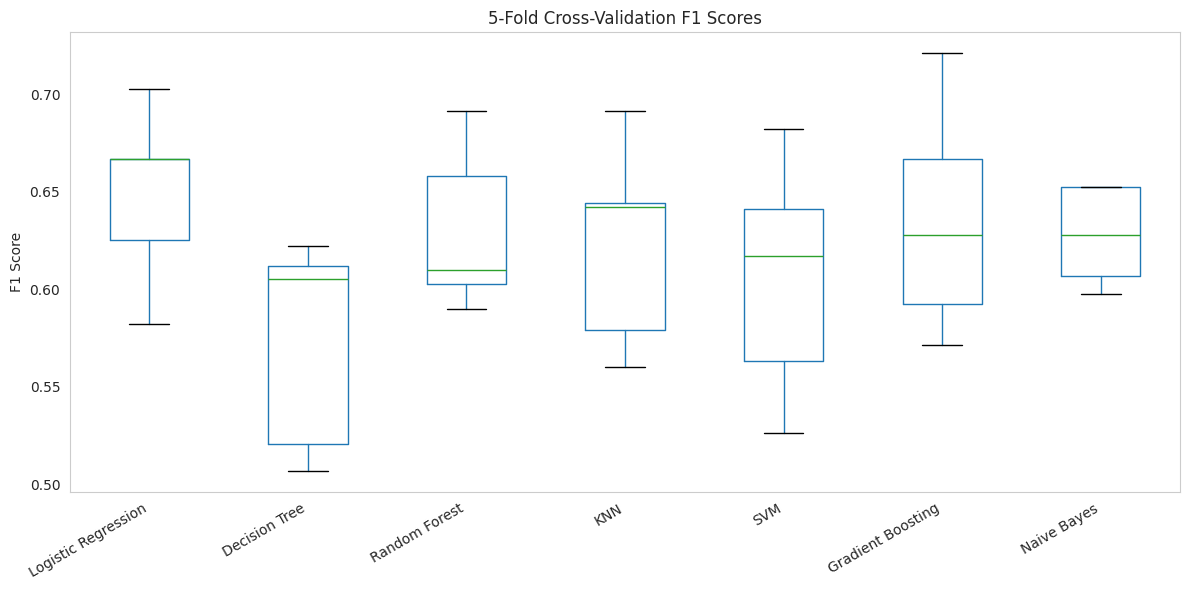

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, grid=False)
ax.set_title("5-Fold Cross-Validation F1 Scores")
ax.set_ylabel("F1 Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 8. ROC Curves

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


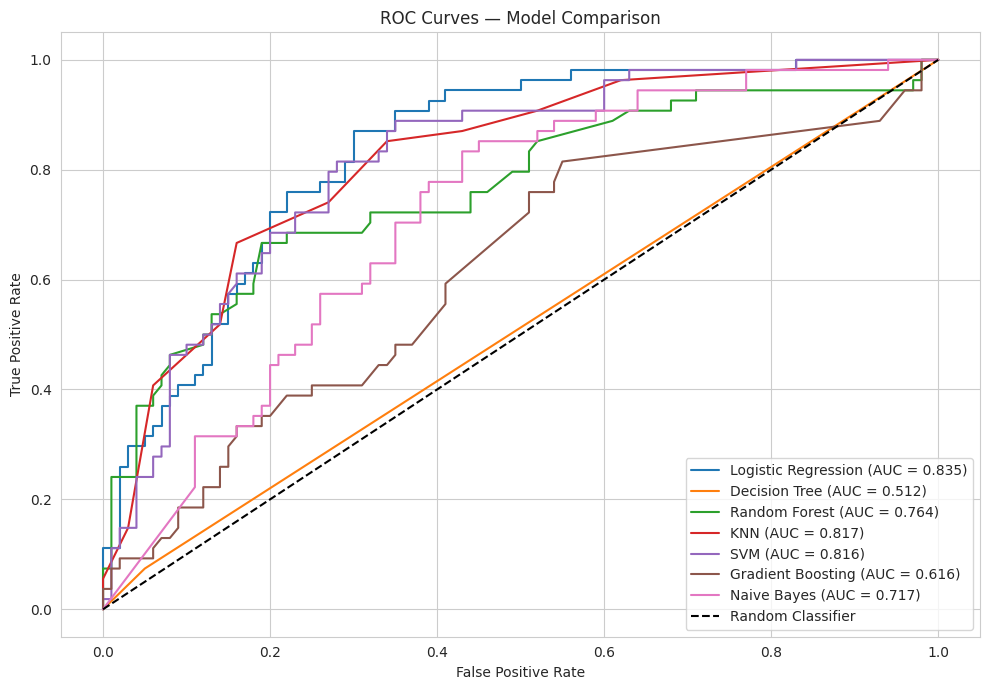

In [41]:
plot_roc_curves(trained_models, X_test_scaled, y_test)

## 9. Hyperparameter Tuning — Random Forest

Grid search over `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`.

In [42]:
param_grid = {
    "n_estimators":      [50, 100, 200],
    "max_depth":         [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"Best Parameters  : {grid_search.best_params_}")
print(f"Best CV F1 Score : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters  : {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Best CV F1 Score : 0.6653



  Random Forest (Tuned)
  Accuracy    : 0.7662
  Precision   : 0.6957
  Recall      : 0.5926
  F1 Score    : 0.6400


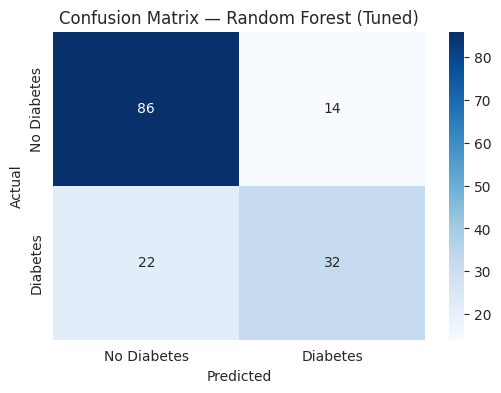

In [43]:
best_rf       = grid_search.best_estimator_
y_pred_tuned  = best_rf.predict(X_test)
metrics_tuned = evaluate_model("Random Forest (Tuned)", y_test, y_pred_tuned)

plot_confusion_matrix(y_test, y_pred_tuned, "Random Forest (Tuned)")
plt.show()

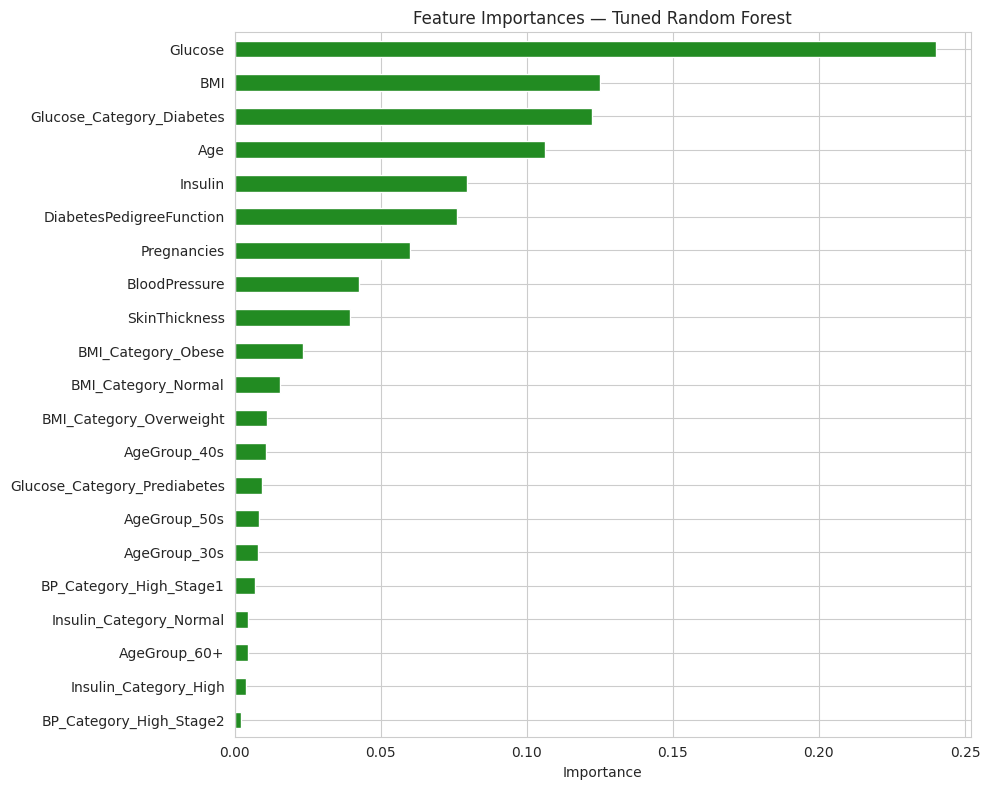

In [44]:
feat_imp_tuned = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 8))
feat_imp_tuned.plot(kind="barh", color="forestgreen")
plt.title("Feature Importances — Tuned Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 10. Sample Prediction

In [45]:
sample      = X_test.iloc[[0]]
prediction  = best_rf.predict(sample)[0]
probability = best_rf.predict_proba(sample)[0]

print("Sample Patient Features:")
for col, val in sample.iloc[0].items():
    print(f"  {col}: {val}")

print(f"\nPrediction     : {'Diabetic' if prediction == 1 else 'Not Diabetic'}")
print(f"Confidence     : {probability[prediction]:.1%}")
print(f"  P(No Diabetes) = {probability[0]:.3f}")
print(f"  P(Diabetes)    = {probability[1]:.3f}")

Sample Patient Features:
  Pregnancies: 7
  Glucose: 159.0
  BloodPressure: 64.0
  SkinThickness: 29.0
  Insulin: 125.0
  BMI: 27.4
  DiabetesPedigreeFunction: 0.294
  Age: 40
  BMI_Category_Normal: False
  BMI_Category_Overweight: True
  BMI_Category_Obese: False
  AgeGroup_30s: True
  AgeGroup_40s: False
  AgeGroup_50s: False
  AgeGroup_60+: False
  Glucose_Category_Prediabetes: False
  Glucose_Category_Diabetes: True
  Insulin_Category_Normal: True
  Insulin_Category_High: False
  BP_Category_High_Stage1: False
  BP_Category_High_Stage2: False

Prediction     : Diabetic
Confidence     : 57.4%
  P(No Diabetes) = 0.426
  P(Diabetes)    = 0.574


## 11. Final Model Summary

In [46]:
all_results = results + [metrics_tuned]
df_final    = compare_models(all_results)
df_final

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.779221,0.692308,0.666667,0.679245
1,Decision Tree,0.740260,0.606061,0.740741,0.666667
2,Random Forest,0.772727,0.702128,0.611111,0.653465
3,SVM,0.753247,0.648148,0.648148,0.648148
4,Random Forest (Tuned),0.766234,0.695652,0.592593,0.640000
5,Gradient Boosting,0.753247,0.666667,0.592593,0.627451
6,Naive Bayes,0.701299,0.560606,0.685185,0.616667
7,Logistic Regression,0.746753,0.659574,0.574074,0.613861


### Key Takeaways

1. **Glucose** is the most predictive feature across all models.
2. **Ensemble methods** (Random Forest, Gradient Boosting) consistently outperform simpler classifiers.
3. **Feature engineering** (BMI / Glucose / Age categories) adds interpretable signal beyond raw numerics.
4. **Hyperparameter tuning** of Random Forest provides additional F1 gains over the baseline configuration.